In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [13]:
kf = 30.0       # konstanta pembentukan kompleks
kr = 1.0        # konstanta dissociation
k2 = 10.0       # konstanta pembentukan produk
Et = 1.0        # total konsentrasi enzim

In [14]:
# Kondisi awal
E0 = Et
S0 = 5.0
C0 = 0.0
P0 = 0.0


In [15]:
# Waktu simulasi
t_start = 0
t_end = 2.5
n_points = 500

t_eval = np.linspace(t_start, t_end, n_points)


Model Michaelis Menten 4 persamaan

In [16]:
def model_4(t, y):

    E, S, C, P = y

    # Reaction rates
    v_forward = kf * E * S
    v_reverse = kr * C
    v_product = k2 * C

    # ODE
    dE_dt = -v_forward + v_reverse + v_product
    dS_dt = -v_forward + v_reverse
    dC_dt = v_forward - v_reverse - v_product
    dP_dt = v_product

    return [dE_dt, dS_dt, dC_dt, dP_dt]

Model Michaelis Menten 3 persamaan

In [17]:
def model_3(t, y):

    S, C, P = y

    # Enzyme diperoleh dari conservation law
    E = Et - C

    # Reaction rates
    v_forward = kf * E * S
    v_reverse = kr * C
    v_product = k2 * C

    # ODE
    dS_dt = -v_forward + v_reverse
    dC_dt = v_forward - v_reverse - v_product
    dP_dt = v_product

    return [dS_dt, dC_dt, dP_dt]

simulasi 4 model

In [18]:
solution_4 = solve_ivp(
    model_4,
    [t_start, t_end],
    [E0, S0, C0, P0],
    t_eval=t_eval,
    method='LSODA'
)

E_4 = solution_4.y[0]
S_4 = solution_4.y[1]
C_4 = solution_4.y[2]
P_4 = solution_4.y[3]

simulasi 3 model

In [19]:
solution_3 = solve_ivp(
    model_3,
    [t_start, t_end],
    [S0, C0, P0],
    t_eval=t_eval,
    method='LSODA'
)

S_3 = solution_3.y[0]
C_3 = solution_3.y[1]
P_3 = solution_3.y[2]

E_3 = Et - C_3

Grafik 1 : substrat

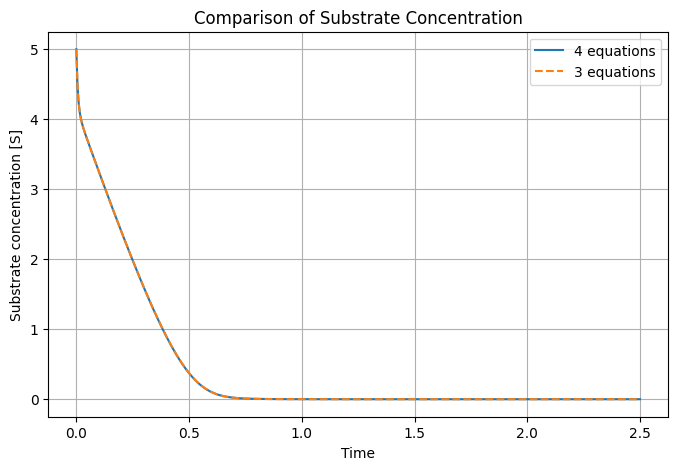

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(t_eval, S_4, label='4 equations')
plt.plot(t_eval, S_3, '--', label='3 equations')

plt.xlabel('Time')
plt.ylabel('Substrate concentration [S]')
plt.title('Comparison of Substrate Concentration')

plt.legend()
plt.grid()
plt.show()

Grafik 2 : enzim

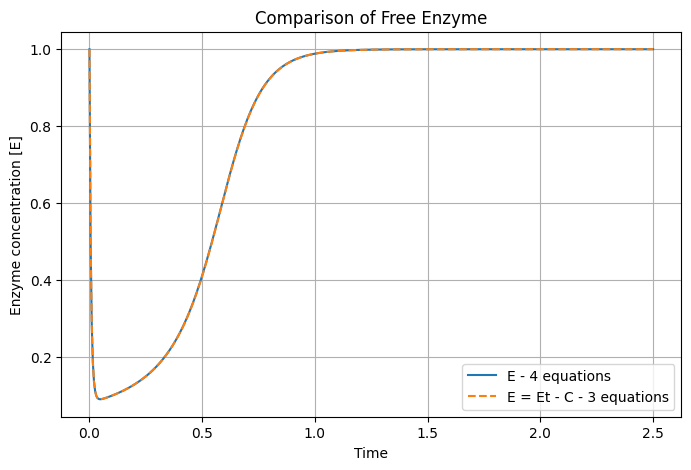

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(t_eval, E_4, label='E - 4 equations')
plt.plot(t_eval, E_3, '--', label='E = Et - C - 3 equations')

plt.xlabel('Time')
plt.ylabel('Enzyme concentration [E]')
plt.title('Comparison of Free Enzyme')

plt.legend()
plt.grid()
plt.show()

Grafik 3 : Enzim Substrat

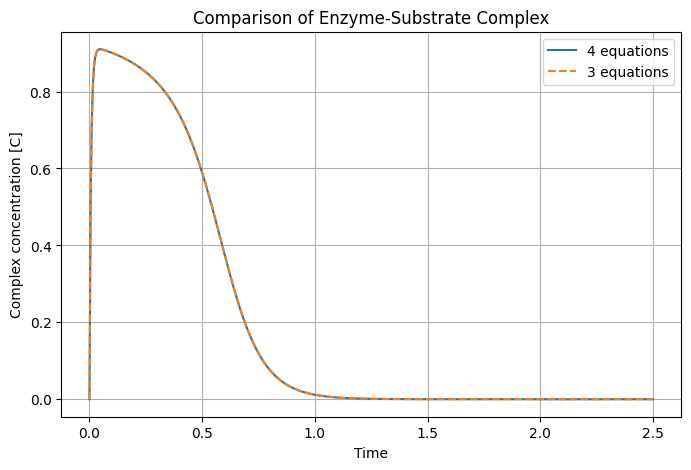

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(t_eval, C_4, label='4 equations')
plt.plot(t_eval, C_3, '--', label='3 equations')

plt.xlabel('Time')
plt.ylabel('Complex concentration [C]')
plt.title('Comparison of Enzyme-Substrate Complex')

plt.legend()
plt.grid()
plt.show()

Grafik 4 : Product

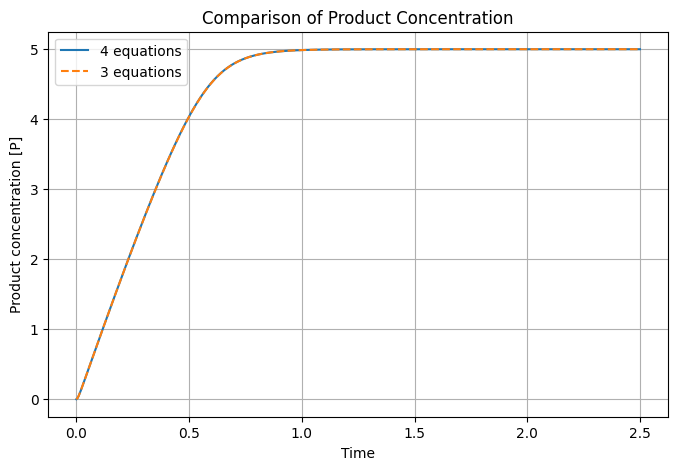

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(t_eval, P_4, label='4 equations')
plt.plot(t_eval, P_3, '--', label='3 equations')

plt.xlabel('Time')
plt.ylabel('Product concentration [P]')
plt.title('Comparison of Product Concentration')

plt.legend()
plt.grid()
plt.show()

Perbandingan

In [24]:
error_S = np.max(np.abs(S_4 - S_3))
error_C = np.max(np.abs(C_4 - C_3))
error_P = np.max(np.abs(P_4 - P_3))
error_E = np.max(np.abs(E_4 - E_3))

print("======================================")
print("COMPARISON")
print("======================================")

print(f"Maximum error S = {error_S:.10e}")
print(f"Maximum error C = {error_C:.10e}")
print(f"Maximum error P = {error_P:.10e}")
print(f"Maximum error E = {error_E:.10e}")

COMPARISON
Maximum error S = 3.4969644556e-03
Maximum error C = 1.5917756251e-03
Maximum error P = 4.0690054590e-03
Maximum error E = 1.5917756251e-03
